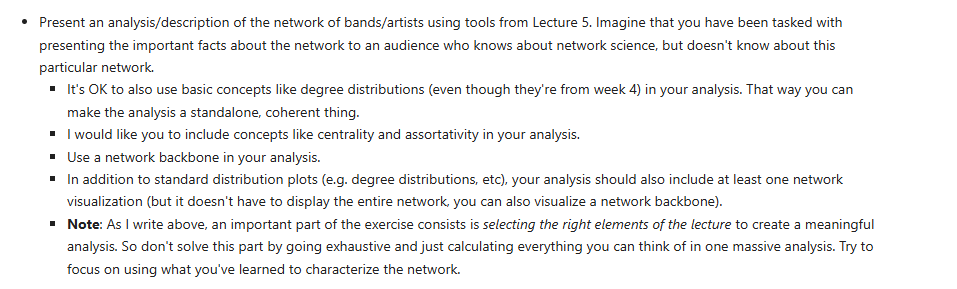

In [119]:
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np
import scipy
import pandas as pd
import seaborn as sns

In [120]:
DG = nx.read_gexf("graphs/rock_bands_graph.gexf")
G = DG.to_undirected()

### Stucture of the analysis
- **Context**
    1. What is the network about
    2. What are the nodes/links and content is also extracted
    3. Giant connected component
        - How many characters are removed?
        -Self-loops removed
    3. What do the links represent (singing together etc.)
- **What can we say about the degrees?**
    1. Basic stats of in and out(mean, mode, min, max)
    2. Compare in- and out-degrees. Correlation and maybe heatmap?
    2. Degree distributions compared to powerlaw, log-normal and exponential distributions. Plot it with all 3 plot-types on top.
        - Can we say anything about what these degree distributions mean?
    3. Alpha-values of powerlaw compared to different regimens
- **What can we say about the centrality of the network**
    1. What are the most connected nodes compared to the 3 centrality types?
        - What is the correlation between the centralities in this network and what can we deduce from that?
            - Should this be plotted?
    2. Is the graph assortative with regards to degree centrality? Why would it be assortative? What is the connection between assortivity and alpha-values?
    3. Important to mention the assortativity in regards to it being a proxy of a network, not the actual network. A link is not a real connection between characters, it's a connection between wiki-pages of characters.
    4. Is the graph assortative with regards to content length (MAYBE? WHERE SHOULD WE TALK ABOUT CONTENT. it's not about the content. It's just about some feature)
    5. How closely does it compare to a random network on shortest path
- **What can we say about the backbone of the network?**
- **Some overall conclusion?**



### MISSING CORREALTION BETWEEN CONTENT AND DEGREES

In [121]:
node_stats = []

for node in DG.nodes():
    in_degree = DG.in_degree(node)
    out_degree = DG.out_degree(node)
    node_stats.append((node, in_degree, out_degree))

df = pd.DataFrame(node_stats, columns = ["Node", "In Degree", "Out Degree"])
df.set_index("Node", inplace = True)

In [122]:
# display(df.describe())

print(df.describe().to_string(float_format="{:.3f}".format))

print("The mode of in-degrees are {} with {} observations".format(scipy.stats.mode(df['In Degree'])[0], scipy.stats.mode(df['In Degree'])[1]))
print("The mode of out-degrees are {} with {} observations".format(scipy.stats.mode(df['Out Degree'])[0], scipy.stats.mode(df['Out Degree'])[1]))

       In Degree  Out Degree
count    461.000     461.000
mean      15.642      15.642
std       16.914      10.593
min        1.000       1.000
25%        4.000       8.000
50%       10.000      14.000
75%       20.000      21.000
max      115.000      72.000
The mode of in-degrees are 3 with 37 observations
The mode of out-degrees are 12 with 27 observations


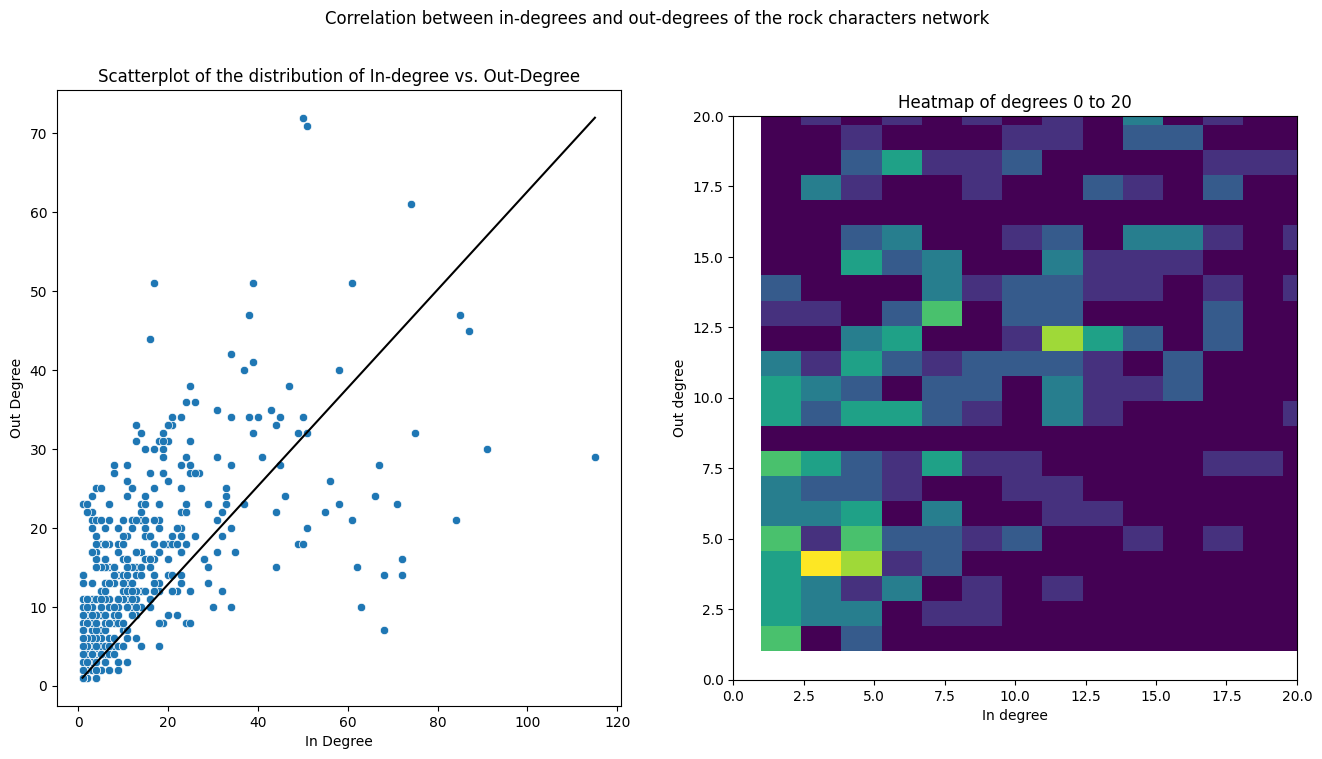

The Pearson correlation is 0.59 and the Spearman correlation is 0.67


In [123]:
figure, axs = plt.subplots(1, 2, figsize=(16, 8)) #Row, col, w, h

#Plot the correlation scatterplot
sns.scatterplot(data = df, x = "In Degree", y = "Out Degree", ax= axs[0])

in_max, out_max = df.max()
in_min, out_min = df.min()

axs[0].plot([in_min,in_max],[out_min,out_max], color = 'black')
axs[0].set_title("Scatterplot of the distribution of In-degree vs. Out-Degree")


#Plot the correlation heatmap
heatmap_data, xedges, yedges = np.histogram2d(df["In Degree"], df["Out Degree"], bins=80)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.imshow(heatmap_data.T, extent=extent, origin='lower')
plt.xlabel("In degree")
plt.ylabel("Out degree")
lim = 20
plt.xlim(0,lim)
plt.ylim(0,lim)
axs[1].set_title("Heatmap of degrees 0 to 20")

############### Show the plot
plt.suptitle("Correlation between in-degrees and out-degrees of the rock characters network")
plt.show()

# Calculate the correlations
cor_pearson = df['In Degree'].corr(df['Out Degree'], method = "pearson")
cor_spearman = df['In Degree'].corr(df['Out Degree'], method = "spearman")

print("The Pearson correlation is {:.2F} and the Spearman correlation is {:.2F}".format(cor_pearson, cor_spearman))

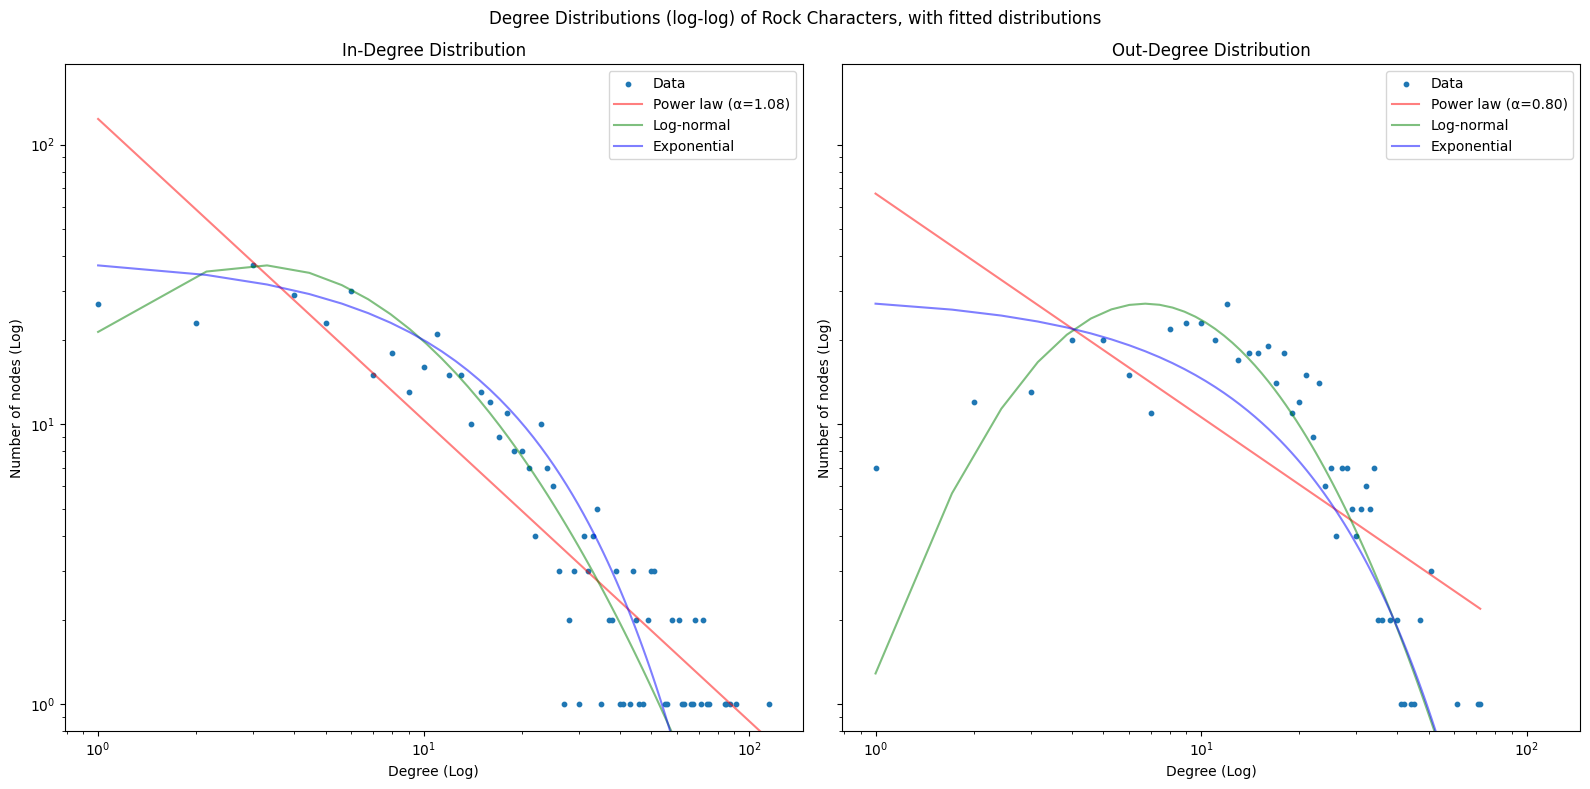

In [124]:
#2 figures. In-degree and out-degree, both should be plotted with Power, log-normal and exponetial fit on top
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

# Helper function for fitting distributions
def fit_and_plot(data, ax, title):
    # Count occurrences of each degree
    unique_degrees, counts = np.unique(data, return_counts=True)
    
    # Power law fit
    powerlaw = np.polyfit(np.log(unique_degrees), np.log(counts), 1)
    powerlaw_y = np.exp(powerlaw[1]) * unique_degrees**powerlaw[0]
    
    # Log-normal fit
    # shape, loc, scale = scipy.stats.lognorm.fit(data)
    shape, loc, scale = scipy.stats.lognorm.fit(data, floc=0)
    # lognorm_x = np.linspace(min(data), max(data), 100)
    lognorm_x = np.linspace(1, max(data), 100)
    lognorm_pdf = scipy.stats.lognorm.pdf(lognorm_x, shape, loc, scale)
    # Scale PDF to match the count data
    scale_factor = counts.max() / lognorm_pdf.max()
    lognorm_y = lognorm_pdf * scale_factor
    
    # Exponential fit
    exp_fit = scipy.stats.expon.fit(data)
    exp_x = np.linspace(min(data), max(data), 100)
    exp_pdf = scipy.stats.expon.pdf(exp_x, *exp_fit)
    # Scale PDF to match the count data
    scale_factor = counts.max() / exp_pdf.max()
    exp_y = exp_pdf * scale_factor
    
    # Plot
    ax.scatter(unique_degrees, counts, alpha=1, s=10, label='Data')
    ax.plot(unique_degrees, powerlaw_y, 'r-', label=f'Power law (α={-powerlaw[0]:.2f})', alpha=0.5)
    ax.plot(lognorm_x, lognorm_y, 'g-', label='Log-normal', alpha=0.5)
    ax.plot(exp_x, exp_y, 'b-', label='Exponential', alpha=0.5)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (Log)')
    ax.set_ylabel('Number of nodes (Log)')
    ax.set_title(title)
    ax.set_ylim(bottom=0.8)  # Set lower limit close to 0 for log scale
    ax.legend()

# Plot for in-degree and out-degree
fit_and_plot(df['In Degree'], ax1, 'In-Degree Distribution')
fit_and_plot(df['Out Degree'], ax2, 'Out-Degree Distribution')

plt.suptitle("Degree Distributions (log-log) of Rock Characters, with fitted distributions")
plt.tight_layout()
plt.show()


In [125]:
df['Degree Centrality'] = nx.degree_centrality(DG)
df['Betweenness Centrality'] = nx.betweenness_centrality(DG)
df['Eigenvector Centrality'] = nx.eigenvector_centrality(DG)

df['Degree Centrality'] = df['Degree Centrality'].round(5)
df['Betweenness Centrality'] = df['Betweenness Centrality'].round(5)
df['Eigenvector Centrality'] = df['Eigenvector Centrality'].round(5)

In [126]:
top5_summary = pd.DataFrame({
    'Degree Centrality': df['Degree Centrality'].nlargest(5),
    'Betweenness Centrality': df['Betweenness Centrality'].nlargest(5),
    'Eigenvector Centrality': df['Eigenvector Centrality'].nlargest(5)
}).fillna("Not in top 5")


print(top5_summary.to_string(float_format="{:.3f}".format))

                Degree Centrality Betweenness Centrality Eigenvector Centrality
Node                                                                           
Alice in Chains      Not in top 5                  0.036           Not in top 5
Black Sabbath               0.293                  0.035                  0.200
Deep Purple                 0.265                  0.046           Not in top 5
Jimi Hendrix         Not in top 5                  0.035           Not in top 5
Kiss (band)          Not in top 5           Not in top 5                  0.162
Led Zeppelin                0.313           Not in top 5                  0.225
Metallica                   0.287           Not in top 5                  0.188
Queen (band)                0.287                  0.041                  0.183


In [127]:
cor_Degree_Between = df['Degree Centrality'].corr(df['Betweenness Centrality'], method = "pearson")
cor_Degree_Eigen = df['Degree Centrality'].corr(df['Eigenvector Centrality'], method = "pearson")
cor_Between_Eigen = df['Betweenness Centrality'].corr(df['Eigenvector Centrality'], method = "pearson")

print(f"Correlation between Degree and Betweenness Centrality: {cor_Degree_Between:.3f}")
print(f"Correlation between Degree and Eigenvector Centrality: {cor_Degree_Eigen:.3f}")
print(f"Correlation between Betweenness and Eigenvector Centrality: {cor_Between_Eigen:.3f}")

Correlation between Degree and Betweenness Centrality: 0.875
Correlation between Degree and Eigenvector Centrality: 0.920
Correlation between Betweenness and Eigenvector Centrality: 0.775


In [128]:
df['Avg Neighbour Degree'] = nx.average_neighbor_degree(DG)
df['Content Length'] = nx.get_node_attributes(DG, "content_length")

#For assortivity in content nx.attribute_assortativity_coefficient(DG, "content_length")
df

,In Degree,Out Degree,Degree Centrality,Betweenness Centrality,Eigenvector Centrality,Avg Neighbour Degree,Content Length
Node,,,,,,,
10 Years (band),7,10,0.03696,0.00089,0.01243,23.900000,4501
Disturbed (band),20,33,0.11522,0.00462,0.03755,23.787879,11700
Breaking Benjamin,21,33,0.11739,0.00648,0.02216,22.303030,16494
Mudvayne,7,15,0.04783,0.00038,0.01956,33.333333,7843
Korn,38,34,0.15652,0.00876,0.08627,26.205882,30035
...,...,...,...,...,...,...,...
The Jesus and Mary Chain,1,13,0.03043,0.00035,0.00310,15.307692,9465
Smash Mouth,1,14,0.03261,0.00019,0.00027,18.571429,9336
Smokie (band),1,2,0.00652,0.00010,0.00157,17.500000,4730


In [129]:
df.to_csv("graphs/node_df.csv", index = True)
# df = pd.read_csv("graphs/node_df.csv", index_col = "Node")

In [130]:
#Compare to random

######################################## IS ThIS SUPPOSED TO BE ON THE UN-DIRECTED GRAPH?
n_nodes = len(DG.nodes)
n_edges = len(DG.edges)

ER = nx.erdos_renyi_graph(n = n_nodes, p =  n_edges/(n_nodes*(n_nodes-1)))

print("The average shortest path length of the undirected rock network is:", nx.average_shortest_path_length(DG))
print("The average shortest path length of the random network is:", nx.average_shortest_path_length(ER))

The average shortest path length of the undirected rock network is: 2.8284212015467323
The average shortest path length of the random network is: 2.5438366500047156


In [131]:
# BACKBONE
import backboning

g_df = nx.to_pandas_edgelist(G, source = "src", target = "trg") #Construct edgelist df from graph
g_df.drop(columns = ['id'], inplace=True) #Drop the generated "id" column
g_df['nij'] = 1.0 #Set edge weight to 1

hss_df = backboning.high_salience_skeleton(g_df)



Calculating HSS score...


In [132]:
percentage_kept = 0.10 #What percentage of links are we keeping?

threshold_value = np.quantile(hss_df['score'], 1-percentage_kept) 

backbone_df = backboning.thresholding(hss_df, threshold_value)

HSS_G = nx.from_pandas_edgelist(df = backbone_df, source = "src", target= "trg", edge_attr="score"
                                , create_using=nx.DiGraph)


backbone_df

,src,trg,nij,score
5,10 Years (band),Stone Temple Pilots,1.0,0.993492
6,10 Years (band),Thousand Foot Krutch,1.0,0.993492
8,10 Years (band),Shinedown,1.0,0.991323
9,10 Years (band),Puddle of Mudd,1.0,0.982646
14,Disturbed (band),Marilyn Manson (band),1.0,0.865510
...,...,...,...,...
5518,Beastie Boys,Sly and the Family Stone,1.0,0.852495
5711,Muse (band),Starset,1.0,0.841649
5755,Buddy Holly,The Big Bopper,1.0,0.819957
5758,Buddy Holly,Cake (band),1.0,0.811280


In [133]:
# set(nx.neighbors(DG, 'Foo Fighters')) & set(nx.neighbors(DG, 'The Beatles'))
# set(HSS_G.predecessors('Foo Fighters')) & set(HSS_G.predecessors('The Beatles'))
what = nx.jaccard_coefficient(HSS_G.to_undirected(), [('Foo Fighters', 'The Beatles')])
for some in what:
    print(some)

('Foo Fighters', 'The Beatles', 0.1)


In [134]:
nx.set_edge_attributes(HSS_G, 
    {edge: d.get('score', 1.0) for edge, d in HSS_G.edges.items()}, 
    'weight'
)



In [135]:
target = 10
for res in [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]:
    comms = nx.community.louvain_communities(HSS_G, weight='weight', resolution=res, seed=42)
    print(f"resolution={res:.2f} → {len(comms)} communities")

resolution=0.00 → 18 communities
resolution=0.01 → 18 communities
resolution=0.10 → 20 communities
resolution=0.20 → 20 communities
resolution=0.30 → 21 communities
resolution=0.40 → 23 communities
resolution=0.50 → 20 communities
resolution=0.60 → 22 communities
resolution=0.80 → 23 communities
resolution=1.00 → 24 communities


In [ ]:
target = 10
for res in [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]:
    comms = nx.community.louvain_communities(DG, weight='weight', resolution=res, seed=42)
    print(f"resolution={res:.2f} → {len(comms)} communities")

    

resolution=0.00 → 1 communities
resolution=0.01 → 1 communities
resolution=0.10 → 1 communities
resolution=0.20 → 1 communities
resolution=0.30 → 1 communities
resolution=0.40 → 1 communities
resolution=0.50 → 2 communities
resolution=0.60 → 3 communities
resolution=0.80 → 3 communities
resolution=1.00 → 5 communities


In [161]:
# df.to_csv("graphs/node_df.csv", index = True)
df = pd.read_csv("graphs/node_df.csv", index_col = "Node")

In [ ]:
louvain_communities = nx.community.louvain_communities(DG, weight='weight', seed = 42)
# df['louvain'] = louvain_communities
# df
louvain_communities[0]
for com_idx, community in enumerate(louvain_communities):
    for node in community:
        df.at[node, 'Louvain'] = com_idx

df.to_csv("graphs/node_df.csv", index = True)

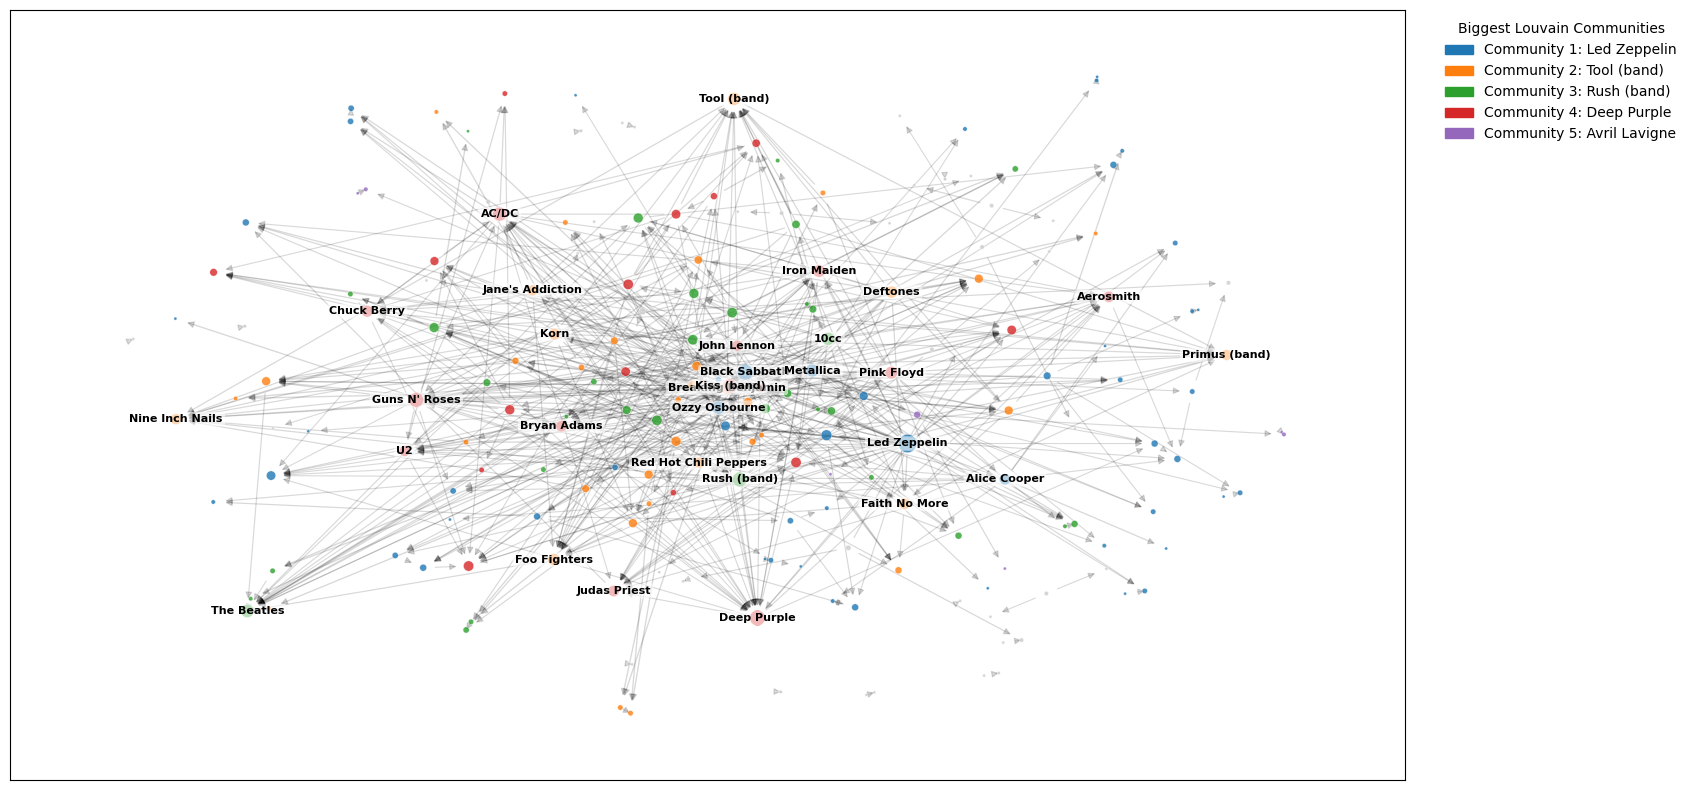

In [140]:
HSS_G_total_degrees = {node: HSS_G.degree(node) for node in HSS_G.nodes()}
HSS_G_node_sizes = [HSS_G_total_degrees[node]*5 for node in HSS_G.nodes()] 
HSS_G_hubs = sorted(HSS_G.degree, key=lambda x: x[1], reverse=True)[:30]
HSS_G_label_nodes = {n for n,_ in HSS_G_hubs}

edge_weights = [weight for (u,v), weight in nx.get_edge_attributes(HSS_G, 'score').items()]

#Plot settings
figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height

nx.set_edge_attributes(HSS_G, 
    {edge: d.get('score', 1.0) for edge, d in HSS_G.edges.items()}, 
    'weight'
)

####################################### ADD LOUVAIN COMMUNITIES
# --- Compute Louvain communities at default resolution ---
communities = community.louvain_communities(HSS_G, weight='weight', seed=42)

# --- Sort communities by size and select top N ---
N = 5  # number of largest communities to color
sorted_communities = sorted(communities, key=len, reverse=True)
top_communities = sorted_communities[:N]

# Assign community indices only for top ones
node_community = {}
for i, comm in enumerate(top_communities):
    for node in comm:
        node_community[node] = i  # 0 to N-1


# --- Color setup ---
colors = []
for node in HSS_G.nodes():
    if node in node_community:
        colors.append(cm.tab10(node_community[node] % 10))  # color for top 5
    else:
        colors.append((0.8, 0.8, 0.8, 0.4))  # light gray for smaller ones

# --- Legend for top communities (representative node = hub) ---
legend_handles = []
for i, comm in enumerate(top_communities):
    top_node = max(comm, key=lambda n: HSS_G.degree(n))
    legend_handles.append(
        mpatches.Patch(color=cm.tab10(i % 10), label=f"Community {i+1}: {top_node}")
    )

# --- Add legend ---
plt.legend(handles=legend_handles, title="Biggest Louvain Communities",
           loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)


########################################## STANDARD PLOTTING
#Get the force atlas positions
force_positions = nx.forceatlas2_layout(HSS_G
                                        ,scaling_ratio = 1
                                        ,gravity=1 #This is cool
                                        ,linlog = True #I LIKE THIS BUT I NEED TO EXPLAIN IT
                                        ,distributed_action=True #EXPLAIN WHAT THIS DOES
                                        )

#Draw edges
nx.draw_networkx_edges(HSS_G, pos = force_positions, alpha = 0.15, edge_color = "k", ax=axs
                       , width=edge_weights
                       )

#Draw nodes
nx.draw_networkx_nodes(HSS_G, pos = force_positions, alpha = 0.8, edgecolors = "white", linewidths = 0.3, ax=axs
                       , node_size=HSS_G_node_sizes, node_color=colors
                       )


nx.draw_networkx_labels(
    HSS_G,
    ax=axs,
    pos=force_positions,              # or use force_positions directly
    labels={node:node if node in HSS_G_label_nodes else '' for node in HSS_G.nodes()},            # only these nodes will get text
    font_size=8,
    font_weight="bold",
    font_color="black",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)  # improves readability
)

plt.show()